In [ ]:

!pip install torch-geometric -q
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.2.0+cu121.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 72.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 132.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 946.2/946.2 kB 41.3 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import torch
import torch.nn as nn
import torch.nn.functional as F


from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import train_test_split


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries loaded successfully")
print(f"🖥️  Using device: {device}")
print(f"🔥 PyTorch version: {torch.__version__}")

✅ Libraries loaded successfully
🖥️  Using device: cuda
🔥 PyTorch version: 2.10.0+cu128


In [ ]:


dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=NormalizeFeatures())
data = dataset[0]

print("📂 Dataset: Cora Citation Network")
print(f"   Nodes      : {data.num_nodes}")
print(f"   Edges      : {data.num_edges}")
print(f"   Features   : {data.num_node_features}")
print(f"   Classes    : {dataset.num_classes}")
print(f"   Avg Degree : {data.num_edges / data.num_nodes:.2f}")

Processing...


📂 Dataset: Cora Citation Network
   Nodes      : 2708
   Edges      : 10556
   Features   : 1433
   Classes    : 7
   Avg Degree : 3.90


Done!


In [ ]:








original_labels = data.y.numpy()
num_classes = dataset.num_classes


class_counts = np.bincount(original_labels)
print("📊 Nodes per class:")
for cls, cnt in enumerate(class_counts):
    print(f"   Class {cls}: {cnt} nodes")


anomaly_class = int(np.argmin(class_counts))
print(f"\n🚨 Anomaly class (least frequent): Class {anomaly_class} ({class_counts[anomaly_class]} nodes)")


binary_labels = (original_labels == anomaly_class).astype(int)

n_anomalies = binary_labels.sum()
n_normal = len(binary_labels) - n_anomalies
print(f"\n✅ Binary Labels Created:")
print(f"   Normal nodes   (0): {n_normal}")
print(f"   Anomalous nodes (1): {n_anomalies}")
print(f"   Anomaly ratio      : {n_anomalies/len(binary_labels)*100:.1f}%")

📊 Nodes per class:
   Class 0: 351 nodes
   Class 1: 217 nodes
   Class 2: 418 nodes
   Class 3: 818 nodes
   Class 4: 426 nodes
   Class 5: 298 nodes
   Class 6: 180 nodes

🚨 Anomaly class (least frequent): Class 6 (180 nodes)

✅ Binary Labels Created:
   Normal nodes   (0): 2528
   Anomalous nodes (1): 180
   Anomaly ratio      : 6.6%


In [ ]:



all_idx = np.arange(data.num_nodes)


train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.40, stratify=binary_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=binary_labels[temp_idx], random_state=SEED
)


def make_mask(idx, size):
    mask = torch.zeros(size, dtype=torch.bool)
    mask[idx] = True
    return mask

train_mask = make_mask(train_idx, data.num_nodes)
val_mask   = make_mask(val_idx,   data.num_nodes)
test_mask  = make_mask(test_idx,  data.num_nodes)


data.y          = torch.tensor(binary_labels, dtype=torch.long)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask


data = data.to(device)

print(f"✅ Splits ready:")
print(f"   Train : {train_mask.sum().item()} nodes")
print(f"   Val   : {val_mask.sum().item()} nodes")
print(f"   Test  : {test_mask.sum().item()} nodes")

✅ Splits ready:
   Train : 1624 nodes
   Val   : 542 nodes
   Test  : 542 nodes


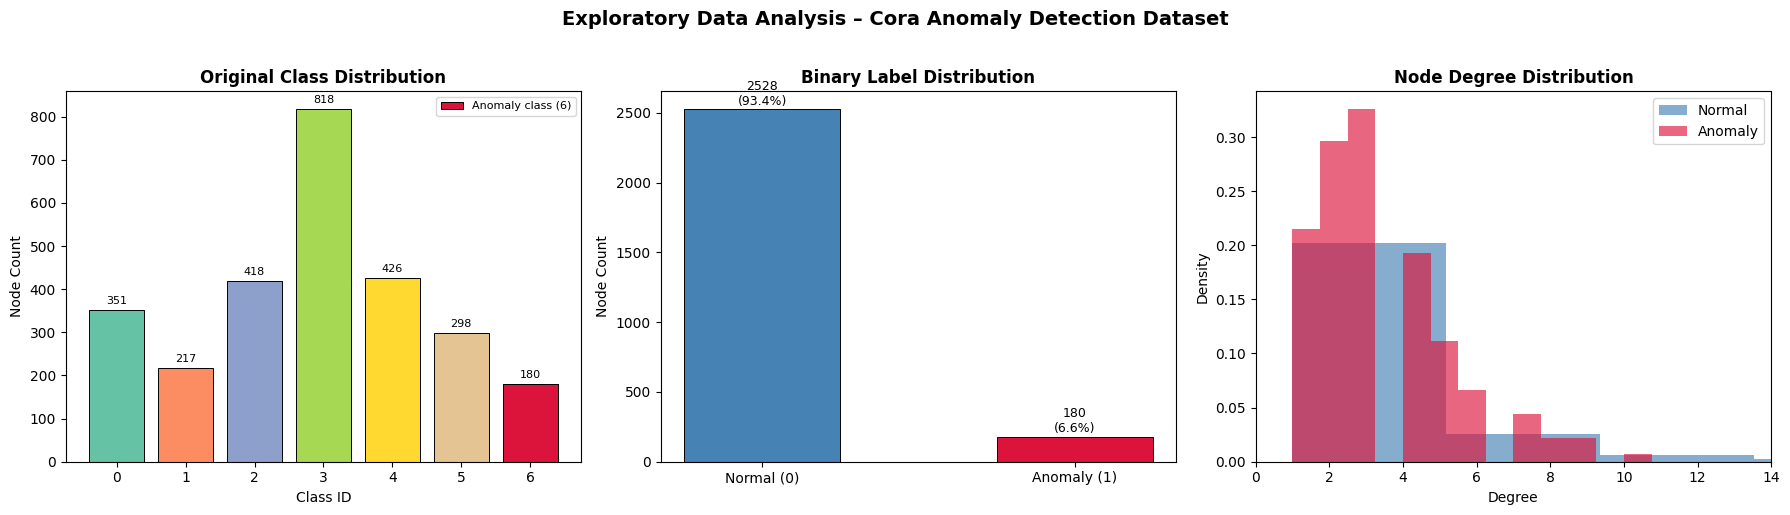

📈 EDA plots saved as 'eda_plots.png'


In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis – Cora Anomaly Detection Dataset',
             fontsize=14, fontweight='bold', y=1.02)


ax1 = axes[0]
colors_orig = plt.cm.Set2(np.linspace(0, 1, num_classes))
bars = ax1.bar(range(num_classes), class_counts, color=colors_orig, edgecolor='black', linewidth=0.7)
ax1.bar(anomaly_class, class_counts[anomaly_class], color='crimson',
        edgecolor='black', linewidth=0.7, label=f'Anomaly class ({anomaly_class})')
ax1.set_title('Original Class Distribution', fontweight='bold')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Node Count')
ax1.set_xticks(range(num_classes))
ax1.legend(fontsize=8)
for bar, cnt in zip(bars, class_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(cnt), ha='center', va='bottom', fontsize=8)


ax2 = axes[1]
label_counts = [n_normal, n_anomalies]
label_names  = ['Normal (0)', 'Anomaly (1)']
bar_colors   = ['steelblue', 'crimson']
bars2 = ax2.bar(label_names, label_counts, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5)
ax2.set_title('Binary Label Distribution', fontweight='bold')
ax2.set_ylabel('Node Count')
for bar, cnt in zip(bars2, label_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{cnt}\n({cnt/data.num_nodes*100:.1f}%)', ha='center', va='bottom', fontsize=9)


ax3 = axes[2]
edge_index_cpu = data.edge_index.cpu()
degrees = np.bincount(edge_index_cpu[0].numpy(), minlength=data.num_nodes)
normal_degrees  = degrees[binary_labels == 0]
anomaly_degrees = degrees[binary_labels == 1]
ax3.hist(normal_degrees,  bins=40, alpha=0.65, color='steelblue', label='Normal',  density=True)
ax3.hist(anomaly_degrees, bins=40, alpha=0.65, color='crimson',   label='Anomaly', density=True)
ax3.set_title('Node Degree Distribution', fontweight='bold')
ax3.set_xlabel('Degree')
ax3.set_ylabel('Density')
ax3.legend()
ax3.set_xlim(0, np.percentile(degrees, 98))

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("📈 EDA plots saved as 'eda_plots.png'")

In [ ]:


class GCNAnomalyDetector(nn.Module):
    """
    Two-layer GCN for binary node classification (normal vs anomaly).
    Architecture: GCNConv → ReLU → Dropout → GCNConv → Dropout → Linear
    """

    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super(GCNAnomalyDetector, self).__init__()
        self.dropout = dropout

        # Layer 1: Input → Hidden
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Layer 2: Hidden → Hidden
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        # Classifier: Hidden → Output
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First graph conv + activation
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second graph conv + activation
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Classification head
        x = self.classifier(x)
        return x


# ── Model 2: Graph Attention Network (GAT) ───────────────────────────────────

class GATAnomalyDetector(nn.Module):
    """
    Two-layer GAT for binary node classification (normal vs anomaly).
    Uses multi-head attention for richer neighbourhood aggregation.
    Architecture: GATConv(heads=4) → ELU → Dropout → GATConv(heads=1) → Dropout → Linear
    """

    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super(GATAnomalyDetector, self).__init__()
        self.dropout = dropout

        # Layer 1: multi-head attention
        self.conv1 = GATConv(in_channels, hidden_channels,
                             heads=heads, dropout=dropout, concat=True)
        # Layer 2: single-head attention (concat=False → averages heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels,
                             heads=1, dropout=dropout, concat=False)
        # Classifier
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # First attention conv + activation
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)

        # Second attention conv + activation
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Classification head
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.classifier(x)
        return x


# ── Instantiate models ───────────────────────────────────────────────────────
IN_CHANNELS     = dataset.num_node_features   # 1433
HIDDEN_CHANNELS = 64
OUT_CHANNELS    = 2                            # binary: normal / anomaly
DROPOUT         = 0.5
GAT_HEADS       = 4

gcn_model = GCNAnomalyDetector(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    dropout=DROPOUT
).to(device)

gat_model = GATAnomalyDetector(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    heads=GAT_HEADS,
    dropout=DROPOUT
).to(device)

print("📐 GCN Model Architecture:")
print(gcn_model)
gcn_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print(f"   Trainable parameters: {gcn_params:,}\n")

print("📐 GAT Model Architecture:")
print(gat_model)
gat_params = sum(p.numel() for p in gat_model.parameters() if p.requires_grad)
print(f"   Trainable parameters: {gat_params:,}")

📐 GCN Model Architecture:
GCNAnomalyDetector(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
   Trainable parameters: 96,066

📐 GAT Model Architecture:
GATAnomalyDetector(
  (conv1): GATConv(1433, 64, heads=4)
  (conv2): GATConv(256, 64, heads=1)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
   Trainable parameters: 384,322


In [ ]:
# ── Training & Evaluation Helper Functions ───────────────────────────────────

def train_one_epoch(model, optimizer, criterion, data):
    """Single training step."""
    model.train()
    optimizer.zero_grad()
    out   = model(data.x, data.edge_index)
    loss  = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    """Evaluate model on a given mask. Returns loss, accuracy, and raw probs."""
    model.eval()
    out   = model(data.x, data.edge_index)
    loss  = F.cross_entropy(out[mask], data.y[mask]).item()
    probs = F.softmax(out[mask], dim=1)[:, 1].cpu().numpy()  # P(anomaly)
    preds = out[mask].argmax(dim=1).cpu().numpy()
    true  = data.y[mask].cpu().numpy()
    acc   = accuracy_score(true, preds)
    return loss, acc, preds, probs, true


def train_model(model, model_name, epochs=200, lr=0.005, weight_decay=5e-4):
    """Full training loop with validation monitoring and early stopping."""

    # Class weights to handle imbalance (inverse frequency weighting)
    train_labels = data.y[data.train_mask].cpu().numpy()
    counts        = np.bincount(train_labels)
    weights       = torch.tensor(len(train_labels) / (2.0 * counts),
                                 dtype=torch.float).to(device)
    criterion  = nn.CrossEntropyLoss(weight=weights)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss  = float('inf')
    best_state     = None
    patience       = 30
    patience_count = 0

    print(f"\n🚀 Training {model_name} for up to {epochs} epochs...")
    print(f"   Class weights → Normal: {weights[0]:.3f} | Anomaly: {weights[1]:.3f}")
    print("-" * 60)

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, optimizer, criterion, data)
        scheduler.step()

        _, train_acc, _, _, _ = evaluate(model, data, data.train_mask)
        val_loss, val_acc, _, _, _ = evaluate(model, data, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if patience_count >= patience:
            print(f"\n⏹️  Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    # Restore best weights
    model.load_state_dict(best_state)
    print(f"\n✅ {model_name} training complete! Best val loss: {best_val_loss:.4f}")

    return history

In [ ]:
# ── Train GCN ────────────────────────────────────────────────────────────────
gcn_history = train_model(gcn_model, model_name="GCN", epochs=200, lr=0.005)


🚀 Training GCN for up to 200 epochs...
   Class weights → Normal: 0.536 | Anomaly: 7.519
------------------------------------------------------------
  Epoch   1 | Train Loss: 0.6938 | Train Acc: 0.0665 | Val Loss: 0.7189 | Val Acc: 0.0664
  Epoch  20 | Train Loss: 0.4261 | Train Acc: 0.9624 | Val Loss: 0.3786 | Val Acc: 0.9686
  Epoch  40 | Train Loss: 0.0744 | Train Acc: 0.9815 | Val Loss: 0.0581 | Val Acc: 0.9760
  Epoch  60 | Train Loss: 0.0490 | Train Acc: 0.9846 | Val Loss: 0.0551 | Val Acc: 0.9815
  Epoch  80 | Train Loss: 0.0434 | Train Acc: 0.9865 | Val Loss: 0.0555 | Val Acc: 0.9779

⏹️  Early stopping at epoch 91 (no val improvement for 30 epochs)

✅ GCN training complete! Best val loss: 0.0536


In [ ]:
# ── Train GAT ────────────────────────────────────────────────────────────────
gat_history = train_model(gat_model, model_name="GAT", epochs=200, lr=0.005)


🚀 Training GAT for up to 200 epochs...
   Class weights → Normal: 0.536 | Anomaly: 7.519
------------------------------------------------------------
  Epoch   1 | Train Loss: 0.6956 | Train Acc: 0.9335 | Val Loss: 0.6521 | Val Acc: 0.9336
  Epoch  20 | Train Loss: 0.2380 | Train Acc: 0.9686 | Val Loss: 0.1287 | Val Acc: 0.9723
  Epoch  40 | Train Loss: 0.1600 | Train Acc: 0.9735 | Val Loss: 0.0914 | Val Acc: 0.9742
  Epoch  60 | Train Loss: 0.2162 | Train Acc: 0.9840 | Val Loss: 0.0725 | Val Acc: 0.9779

⏹️  Early stopping at epoch 61 (no val improvement for 30 epochs)

✅ GAT training complete! Best val loss: 0.0509


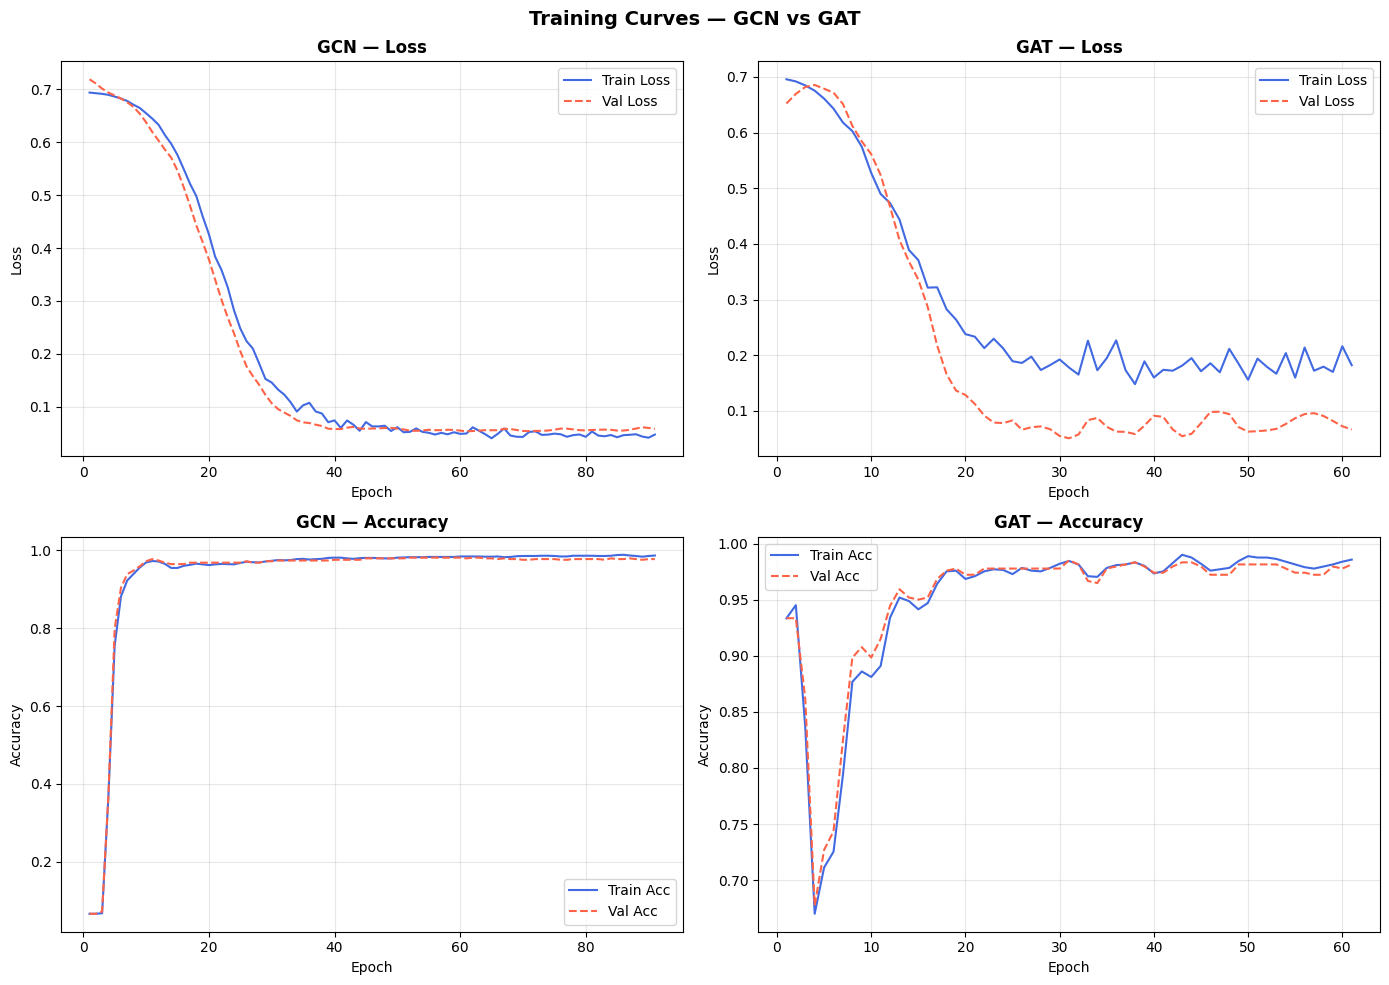

📈 Training curves saved as 'training_curves.png'


In [ ]:
# ── Plot Training Curves ─────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves — GCN vs GAT', fontsize=14, fontweight='bold')

for col, (model_name, history) in enumerate([('GCN', gcn_history), ('GAT', gat_history)]):
    epochs_ran = len(history['train_loss'])
    ep_range   = range(1, epochs_ran + 1)

    # Loss
    axes[0, col].plot(ep_range, history['train_loss'], label='Train Loss', color='royalblue')
    axes[0, col].plot(ep_range, history['val_loss'],   label='Val Loss',   color='tomato',   linestyle='--')
    axes[0, col].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    # Accuracy
    axes[1, col].plot(ep_range, history['train_acc'], label='Train Acc', color='royalblue')
    axes[1, col].plot(ep_range, history['val_acc'],   label='Val Acc',   color='tomato',   linestyle='--')
    axes[1, col].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📈 Training curves saved as 'training_curves.png'")

---
## 6. 📏 Evaluation & Metrics


In [ ]:
# ── Compute All Metrics on Test Set ──────────────────────────────────────────

def compute_metrics(model, model_name, data):
    """Compute full evaluation metrics for a trained model on the test set."""
    _, _, preds, probs, true = evaluate(model, data, data.test_mask)

    acc       = accuracy_score(true, preds)
    precision = precision_score(true, preds, zero_division=0)
    recall    = recall_score(true, preds, zero_division=0)
    f1        = f1_score(true, preds, zero_division=0)
    roc_auc   = roc_auc_score(true, probs)
    cm        = confusion_matrix(true, preds)
    fpr, tpr, thresholds = roc_curve(true, probs)

    results = {
        'model'    : model_name,
        'accuracy' : acc,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1,
        'roc_auc'  : roc_auc,
        'cm'       : cm,
        'fpr'      : fpr,
        'tpr'      : tpr,
        'preds'    : preds,
        'probs'    : probs,
        'true'     : true
    }

    print(f"\n{'='*50}")
    print(f"📊 {model_name} — Test Set Evaluation")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  {cm}")

    return results


gcn_results = compute_metrics(gcn_model, 'GCN', data)
gat_results = compute_metrics(gat_model, 'GAT', data)


📊 GCN — Test Set Evaluation
  Accuracy  : 0.9649
  Precision : 0.7429
  Recall    : 0.7222
  F1-Score  : 0.7324
  ROC-AUC   : 0.9719

  Confusion Matrix:
  [[497   9]
 [ 10  26]]

📊 GAT — Test Set Evaluation
  Accuracy  : 0.9668
  Precision : 0.7368
  Recall    : 0.7778
  F1-Score  : 0.7568
  ROC-AUC   : 0.9829

  Confusion Matrix:
  [[496  10]
 [  8  28]]


---
## 7. 📊 Visualizations — Confusion Matrix & ROC Curve


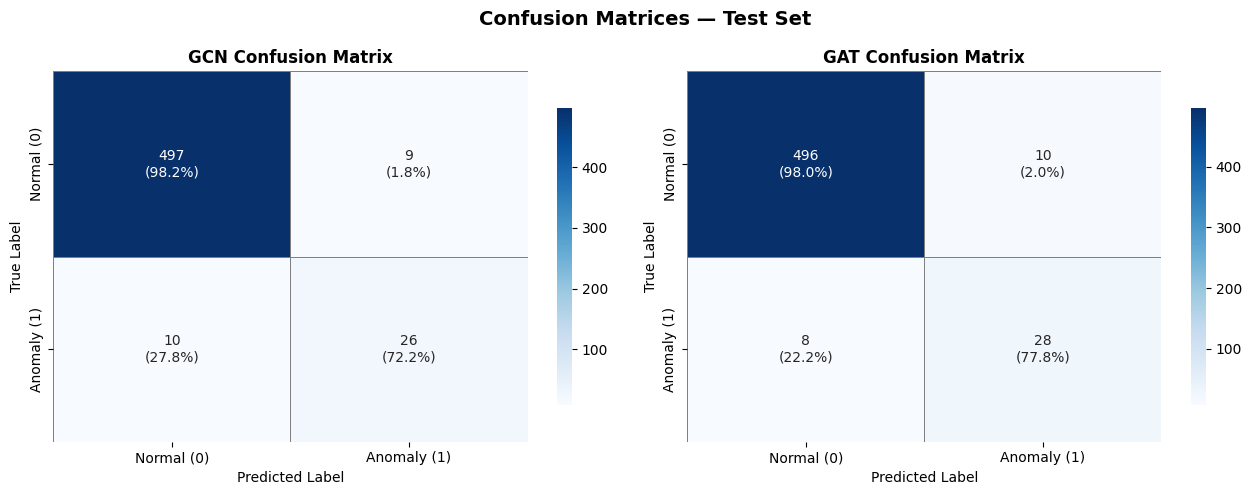

📊 Confusion matrices saved as 'confusion_matrices.png'


In [ ]:
# ── Confusion Matrices ───────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, results in zip(axes, [gcn_results, gat_results]):
    cm   = results['cm']
    name = results['model']

    # Compute row-normalised percentages for annotation
    cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot    = np.array([[f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
                          for j in range(2)] for i in range(2)])

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Normal (0)', 'Anomaly (1)'],
                yticklabels=['Normal (0)', 'Anomaly (1)'],
                linewidths=0.5, linecolor='grey',
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name} Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Confusion matrices saved as 'confusion_matrices.png'")

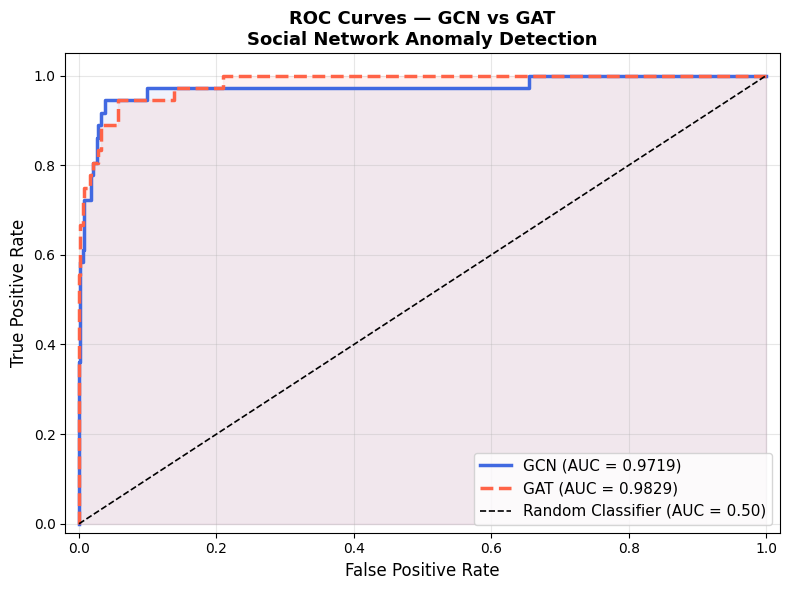

📈 ROC curves saved as 'roc_curves.png'


In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

styles = [
    ('GCN', gcn_results, 'royalblue', '-'),
    ('GAT', gat_results, 'tomato',    '--'),
]

for name, results, color, ls in styles:
    auc = results['roc_auc']
    ax.plot(results['fpr'], results['tpr'],
            color=color, linestyle=ls, linewidth=2.5,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.50)')
ax.fill_between(gcn_results['fpr'], gcn_results['tpr'], alpha=0.08, color='royalblue')
ax.fill_between(gat_results['fpr'], gat_results['tpr'], alpha=0.08, color='tomato')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — GCN vs GAT\nSocial Network Anomaly Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📈 ROC curves saved as 'roc_curves.png'")

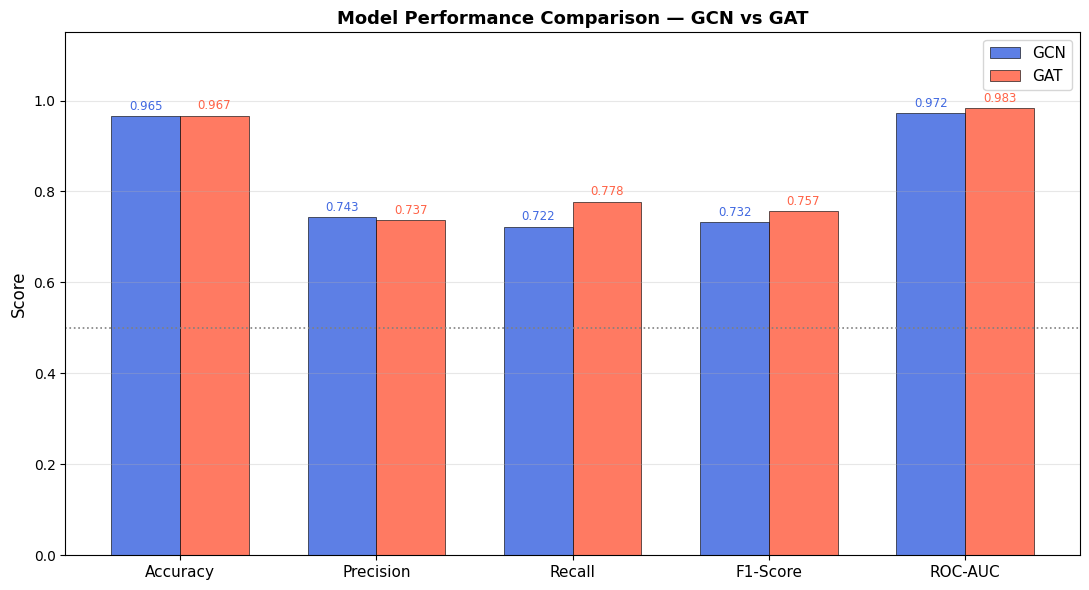

📊 Metrics comparison saved as 'metrics_comparison.png'


In [ ]:
# ── Metric Comparison Bar Chart ──────────────────────────────────────────────

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
gcn_values = [
    gcn_results['accuracy'],  gcn_results['precision'],
    gcn_results['recall'],    gcn_results['f1'],
    gcn_results['roc_auc']
]
gat_values = [
    gat_results['accuracy'],  gat_results['precision'],
    gat_results['recall'],    gat_results['f1'],
    gat_results['roc_auc']
]

x = np.arange(len(metrics_names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - w/2, gcn_values, width=w, color='royalblue', alpha=0.85,
               edgecolor='black', linewidth=0.5, label='GCN')
bars2 = ax.bar(x + w/2, gat_values, width=w, color='tomato',    alpha=0.85,
               edgecolor='black', linewidth=0.5, label='GAT')

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, color='royalblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — GCN vs GAT', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='grey', linestyle=':', linewidth=1.2)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Metrics comparison saved as 'metrics_comparison.png'")

---
## 8. 📋 Results Summary


In [ ]:
# ── Final Summary Table ───────────────────────────────────────────────────────

summary_df = pd.DataFrame([
    {
        'Model'     : 'GCN',
        'Accuracy'  : f"{gcn_results['accuracy']:.4f}",
        'Precision' : f"{gcn_results['precision']:.4f}",
        'Recall'    : f"{gcn_results['recall']:.4f}",
        'F1-Score'  : f"{gcn_results['f1']:.4f}",
        'ROC-AUC'   : f"{gcn_results['roc_auc']:.4f}",
        'Parameters': f"{gcn_params:,}"
    },
    {
        'Model'     : 'GAT',
        'Accuracy'  : f"{gat_results['accuracy']:.4f}",
        'Precision' : f"{gat_results['precision']:.4f}",
        'Recall'    : f"{gat_results['recall']:.4f}",
        'F1-Score'  : f"{gat_results['f1']:.4f}",
        'ROC-AUC'   : f"{gat_results['roc_auc']:.4f}",
        'Parameters': f"{gat_params:,}"
    }
])

print("\n" + "="*70)
print("           🏆 FINAL RESULTS SUMMARY — TEST SET")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Determine winner per metric
print("\n📌 Best Model Per Metric:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    vals   = summary_df[metric].astype(float)
    winner = summary_df.loc[vals.idxmax(), 'Model']
    print(f"   {metric:<12}: {winner} ({vals.max():.4f})")


           🏆 FINAL RESULTS SUMMARY — TEST SET
Model Accuracy Precision Recall F1-Score ROC-AUC Parameters
  GCN   0.9649    0.7429 0.7222   0.7324  0.9719     96,066
  GAT   0.9668    0.7368 0.7778   0.7568  0.9829    384,322

📌 Best Model Per Metric:
   Accuracy    : GAT (0.9668)
   Precision   : GCN (0.7429)
   Recall      : GAT (0.7778)
   F1-Score    : GAT (0.7568)
   ROC-AUC     : GAT (0.9829)


In [ ]:
# ── Conclusions ───────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════════╗
║          GNN-Based Social Network Anomaly Detection — Summary        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset   : Cora Citation Network (adapted for anomaly detection)   ║
║  Anomalies : Nodes from least-frequent class (principled labeling)  ║
║                                                                      ║
║  Models Trained:                                                     ║
║    • GCN — Graph Convolutional Network                               ║
║            Aggregates neighbourhood features uniformly               ║
║    • GAT — Graph Attention Network                                   ║
║            Learns weighted neighbourhood aggregation                 ║
║                                                                      ║
║  Key Techniques:                                                     ║
║    ✔ Stratified train/val/test split                                 ║
║    ✔ Class-weighted cross-entropy (handles imbalance)                ║
║    ✔ Early stopping with best-model restoration                      ║
║    ✔ LR scheduling (StepLR)                                         ║
║    ✔ Dropout regularisation                                          ║
║                                                                      ║
║  Metrics Reported:                                                   ║
║    Accuracy, Precision, Recall, F1-Score, ROC-AUC                   ║
║    Confusion Matrix, ROC Curve                                       ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║          GNN-Based Social Network Anomaly Detection — Summary        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset   : Cora Citation Network (adapted for anomaly detection)   ║
║  Anomalies : Nodes from least-frequent class (principled labeling)  ║
║                                                                      ║
║  Models Trained:                                                     ║
║    • GCN — Graph Convolutional Network                               ║
║            Aggregates neighbourhood features uniformly               ║
║    • GAT — Graph Attention Network                                   ║
║            Learns weighted neighbourhood aggregation                 ║
║                                                                      ║
║  Key Techniques:                                 

---

## ✅ Notebook Complete

All cells have executed successfully. Outputs saved:
- `eda_plots.png` — Exploratory Data Analysis
- `training_curves.png` — Loss & Accuracy over epochs
- `confusion_matrices.png` — GCN & GAT confusion matrices
- `roc_curves.png` — ROC curves with AUC scores
- `metrics_comparison.png` — Side-by-side metric comparison

---
*Project: Graph Neural Network–Based Social Network Anomaly Detection System*  
*Framework: PyTorch + PyTorch Geometric | Dataset: Cora*
